In [1]:
import scanpy as sc
import infercnvpy as cnv
import pandas as pd

/home/sduan/miniforge3/envs/scverse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# adata = sc.read("/home/sduan/projects/sahmi/data/v1/20250920.pan-cancer.integrated.h5ad")
# adata
adata = sc.read("../data/processed/scrup/integrated/20251117/cnv.raw.h5ad")

In [4]:
cnv.io.genomic_position_from_gtf(
    gtf_file="/home/sduan/data/scrup/reference/GRCh38/v48/sources/filtered.gtf",
    adata=adata
)

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'exon_number', 'exon_id', 'transcript_support_level', 'havana_transcript', 'hgnc_id', 'havana_gene', 'protein_id', 'ccdsid']


In [5]:
reference_types = [
        "B cells",
        "Innate lymphoid cells"
]


In [6]:
cnv.tl.infercnv(
    adata,
    reference_key="cell_type_level1",
    reference_cat=reference_types,
    window_size=250,
)

100%|██████████| 271/271 [20:13<00:00,  4.48s/it] 


In [9]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)

/home/sduan/miniforge3/envs/scverse/lib/python3.12/site-packages/infercnvpy/tl/__init__.py:24: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(


In [11]:
cnv.tl.cnv_score(adata)

In [12]:
cnv.tl.umap(adata)

In [ ]:
# cnv.pl.chromosome_heatmap(adata, groupby="cell_type_level1")

... storing 'gene_id' as categorical
... storing 'gene_name' as categorical


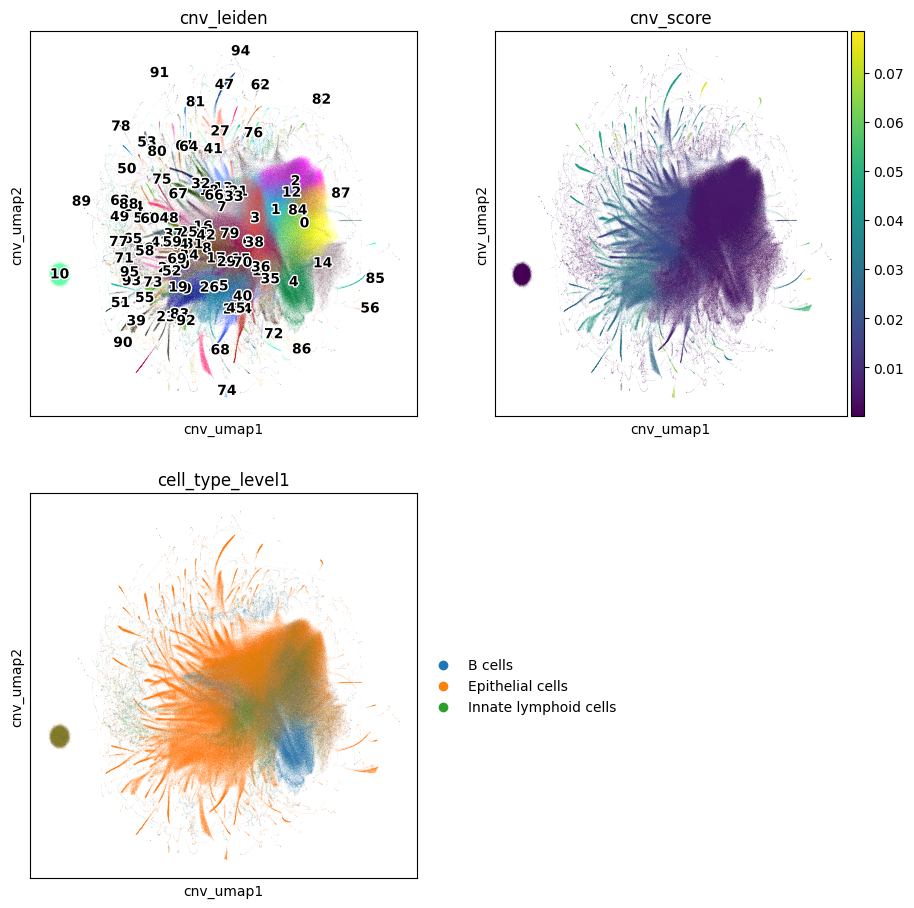

In [14]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="cell_type_level1", ax=ax3)

In [ ]:
# sc.pl.umap(adata, color=["cnv_score","cnv_leiden","cell_type_level1"],legend_loc="on data")

In [25]:
adata.obs["cnv_status"] = "normal"
adata.obs.loc[adata.obs["cnv_leiden"].isin(["43","63","42","61","66","37",
                                                   "34","13","58","20","41","40",
                                                   "60"]), "cnv_status"] = (
    "tumor"
)

In [13]:
adata.obs.to_csv("../data/processed/scrup/integrated/20251117/EP.cnv.csv")

In [28]:
adata.obs["cnv_status"].value_counts()

cnv_status
normal    1126115
tumor       71320
Name: count, dtype: int64

In [29]:
adata

AnnData object with n_obs × n_vars = 1197435 × 19809
    obs: 'sample', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'scDblFinder.class', 'scDblFinder.score', 'study', 'pmid', 'assay', 'rna_source', 'harmonized_disease', 'harmonized_tissue', 'harmonized_sample_type', 'n_microbiome', 'n_cell', 'prop', 'tumor_status', 'library_source', 'library_selection', 'instrument', 'source', 'number_of_reads', 'reads_with_valid_barcodes', 'sequencing_saturation', 'q30_bases_in_cb_umi', 'q30_bases_in_rna_read', 'reads_mapped_to_genome_unique_multiple', 'reads_mapped_to_genome_unique', 'reads_mapped_to_gene_unique_multiple_gene', 'reads_mapped_to_gene_unique_gene', 'estimated_number_of_cells', 'unique_reads_in_cells_mapped_to_gene', 'fraction_of_unique_reads_in_cells', 'mean_reads_per_cell', 'median_reads_per_cell', 'umis_in_cells', 'mean_umi_per_cell', 'median_umi_per_cell', 'mean_gene_per_cell', 'median_gene_per_cell', 'total_gene_detected', 'bacteria', 'eukaryota', 'viruses', 'batch', 'leiden', 'cel

In [ ]:
cnv.pl.umap(adata, color="cnv_status", ax=ax2, show=False)

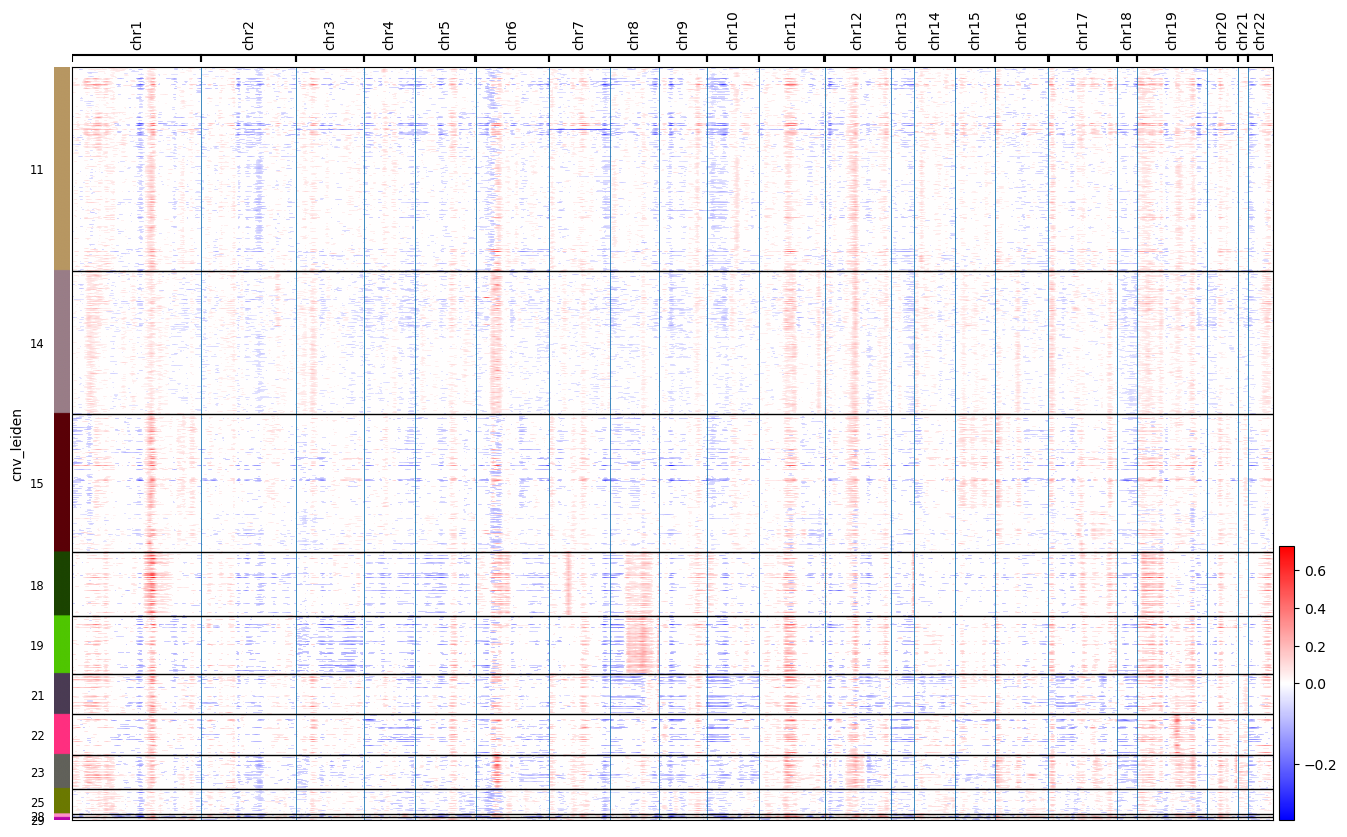

In [19]:
cnv.pl.chromosome_heatmap(adata[adata.obs["cnv_status"] == "tumor", :])

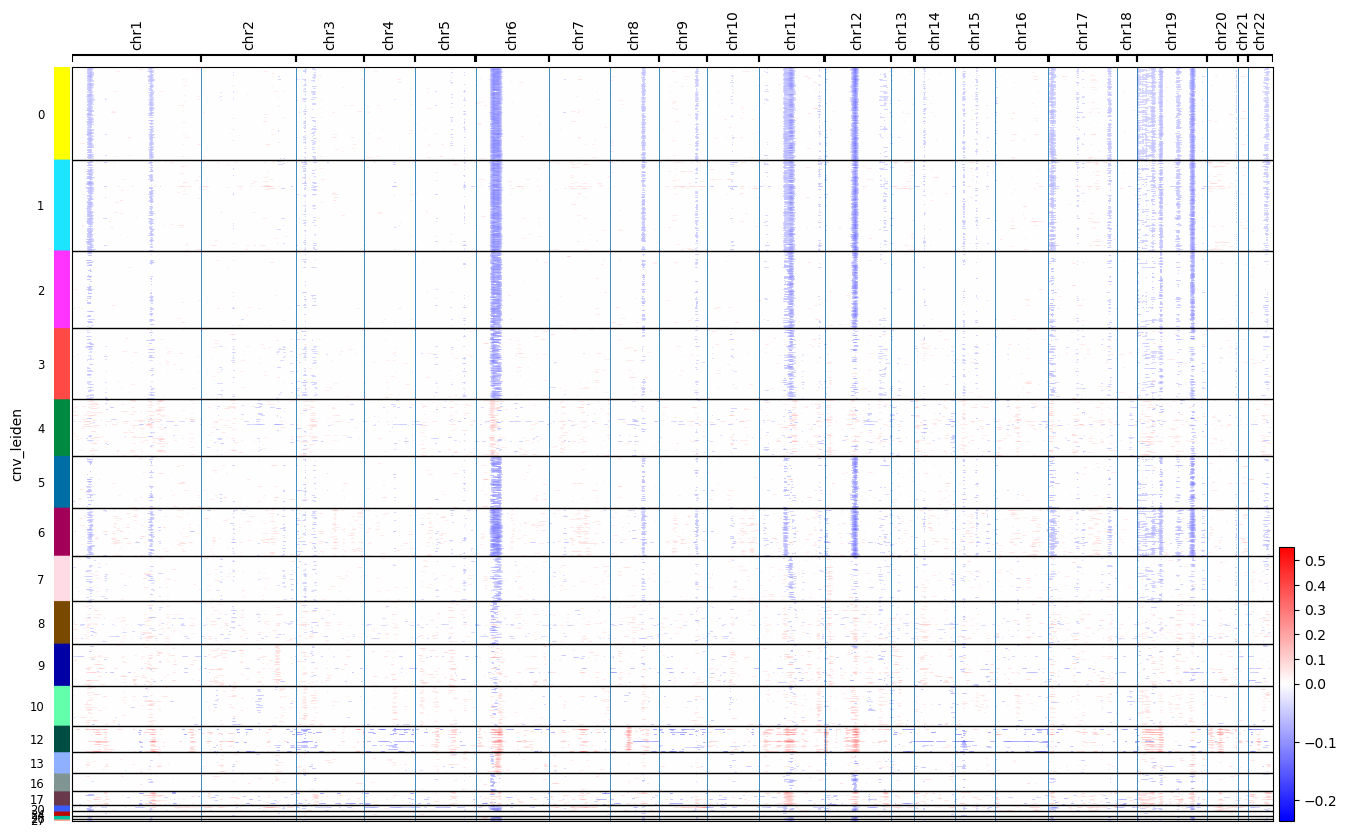

In [21]:
cnv.pl.chromosome_heatmap(adata[adata.obs["cnv_status"] == "normal", :])

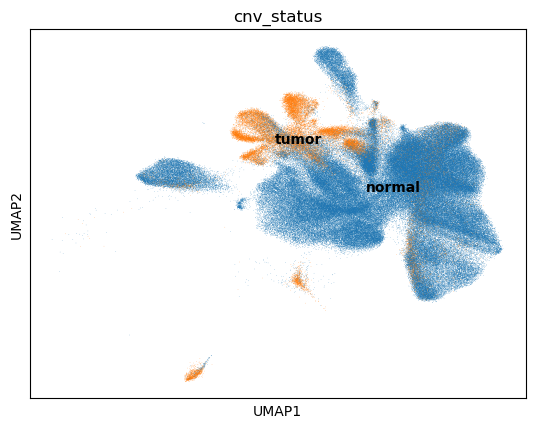

In [20]:
sc.pl.umap(adata, color=["cnv_status"],legend_loc="on data")

In [22]:
adata

AnnData object with n_obs × n_vars = 249741 × 41845
    obs: 'orig.ident', 'nFeature_RNA', 'nCount_RNA', 'percent.mt', 'study', 'assay', 'sample', 'gender', 'age', 'tissue', 'sample_type', 'disease', 'bacteria', 'viruses', 'eukaryota', 'batch', 'leiden', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'cell_type_level1', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'gene_ids', 'feature_types', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'cell_type_level1_colors', 'cnv', 'cnv_neighbors', 'cnv_leiden', 'cnv_leiden_colors', 'cnv_status_colors'
    obsm: 'X_umap', 'X_cnv', 'X_cnv_pca', 'X_cnv_umap'
    obsp: 'cnv_neighbors_distances', 'cnv_neighbors_connectivities'

In [30]:
adata.obs.to_csv("../data/processed/clustering/EP.cnv.csv")